# Final Project - Spam Detection and Email Importance Ranking

**Student:** Ali EL HAGE HASSAN  
**Dataset:** `email_dataset_30k.csv`  
**Main goals:**
1. Build a serious binary classifier to detect spam vs non-spam emails.
2. Build a second-stage model to estimate the business importance level of legitimate emails.
3. Compare several modeling strategies, run robust tests, and document every major step.

## Project positioning

This notebook goes further than the homeworks:
- stronger data audit
- feature engineering from text and metadata
- model comparison instead of a single model
- cross-validation, holdout testing, threshold analysis, temporal validation, subgroup checks
- error analysis and interpretability
- a transparent importance scoring framework for non-spam emails


## Methodological Notes

A few important points before we start:

- The column `label` is the ground-truth target for the spam classification task.
- The dataset appears synthetic and highly structured, so extremely high spam performance must be interpreted carefully.
- The column `x_spam_score` looks like an already-existing anti-spam signal. For that reason, we evaluate both:
  - a **strict** setting without depending on this prior score
  - a **full operational** setting that includes it
- There is **no ground-truth importance label** in the CSV. Therefore, for the second task, we create a transparent and documented **business importance score** on non-spam emails, then convert it into three levels:
  - `low`
  - `medium`
  - `high`


In [1]:
# Core imports used throughout the project.
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_PATH = Path("email_dataset_30k.csv")
RANDOM_STATE = 42

FREE_MAIL_PROVIDERS = {
    "gmail.com",
    "googlemail.com",
    "outlook.com",
    "hotmail.com",
    "live.com",
    "icloud.com",
    "me.com",
    "yahoo.com",
    "proton.me",
    "protonmail.com",
    "aol.com",
    "gmx.com",
    "mail.com",
}

print("Working directory:", Path.cwd())
print("Dataset found:", DATA_PATH.exists())


Working directory: /Users/alielhagehassan/Desktop/emlyon/ML/HomeWork/Final Project
Dataset found: True


In [2]:
# Load the dataset and inspect the first rows.
data_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", data_raw.shape)
print("\nColumn list:")
print(list(data_raw.columns))

print("\nFirst 3 rows:")
print(data_raw.head(3).to_string())


Raw shape: (30000, 30)

Column list:
['raw_text', 'subject', 'body_plain', 'body_html', 'from_address', 'from_domain', 'reply_to', 'to_addresses', 'cc_addresses', 'date', 'hour_of_day', 'message_id', 'in_reply_to', 'num_received_headers', 'received_origin_ip', 'spf_result', 'dkim_result', 'dmarc_result', 'has_attachments', 'attachment_types', 'has_html', 'num_urls', 'num_emails_in_body', 'num_phone_numbers', 'contains_tracking_token', 'x_spam_score', 'user_agent', 'list_unsubscribe', 'language', 'label']

First 3 rows:
                                                                                                                                                                                                           raw_text                      subject                                                                                                                                                                    body_plain body_html              from_address from_domain reply_to    

In [3]:
# Perform a first audit: data types, missing values, duplicate signals, and target balance.
missing_ratio = (data_raw.isna().mean() * 100).sort_values(ascending=False).round(2)

audit_table = pd.DataFrame(
    {
        "dtype": data_raw.dtypes.astype(str),
        "missing_pct": (data_raw.isna().mean() * 100).round(2),
        "n_unique": data_raw.nunique(dropna=False),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Dataset audit table:")
print(audit_table.to_string())

print("\nTop missing percentages:")
print(missing_ratio.head(15).to_string())

print("\nDuplicate checks:")
print("Duplicate message_id:", int(data_raw["message_id"].duplicated().sum()))
print("Duplicate raw_text:", int(data_raw["raw_text"].duplicated().sum()))
print(
    "Duplicate subject+body:",
    int((data_raw["subject"].fillna("") + " || " + data_raw["body_plain"].fillna("")).duplicated().sum()),
)

print("\nSpam label distribution:")
print(data_raw["label"].value_counts(normalize=True).sort_index().round(4).to_string())


Dataset audit table:
                           dtype  missing_pct  n_unique
in_reply_to                  str        84.87      4541
cc_addresses                 str        80.24      5848
list_unsubscribe             str        80.17      5951
attachment_types             str        79.66      6101
reply_to                     str        70.13      6594
body_html                    str        57.61     11992
message_id                   str         0.00     30000
received_origin_ip           str         0.00     30000
date                         str         0.00     29892
raw_text                     str         0.00     29308
body_plain                   str         0.00     25357
from_address                 str         0.00     20339
to_addresses                 str         0.00     20162
subject                      str         0.00      5935
x_spam_score             float64         0.00       802
hour_of_day                int64         0.00        24
from_domain                

## Feature Engineering

We now create a cleaner modeling table with:
- text variables combined into one main field
- parsed date features
- engineered counts for recipients and attachments
- text-shape indicators such as uppercase ratio and digit ratio
- sender-domain type (`free mail` vs not)
- authentication summary (`auth_pass_count`)
- duplicate removal on exact `raw_text` to reduce leakage between train and test


In [4]:
# Build reusable helper functions for preprocessing and evaluation.
def count_addresses(value):
    # Count comma- or semicolon-separated email addresses.
    if pd.isna(value) or str(value).strip() == "":
        return 0
    return len([item for item in re.split(r"[;,]", str(value)) if item.strip()])


def count_attachments(value):
    # Count attachment names separated by semicolons.
    if pd.isna(value) or str(value).strip() == "":
        return 0
    return len([item for item in str(value).split(";") if item.strip()])


def upper_ratio(text):
    # Share of uppercase letters in a piece of text.
    text = "" if pd.isna(text) else str(text)
    letters = [char for char in text if char.isalpha()]
    if not letters:
        return 0.0
    return sum(char.isupper() for char in letters) / len(letters)


def digit_ratio(text):
    # Share of digits in a piece of text.
    text = "" if pd.isna(text) else str(text)
    if len(text) == 0:
        return 0.0
    return sum(char.isdigit() for char in text) / len(text)


def build_feature_frame(df):
    # Create a modeling-ready dataframe while keeping traceability.
    out = df.copy()

    # Parse the timestamp first because many derived features depend on it.
    out["date"] = pd.to_datetime(out["date"], errors="coerce")

    # Main text field used for NLP models.
    out["combined_text"] = (
        out["subject"].fillna("")
        + " "
        + out["body_plain"].fillna("")
        + " "
        + out["body_html"].fillna("")
    ).str.strip()

    # Structural counts derived from address and attachment fields.
    out["to_count"] = out["to_addresses"].apply(count_addresses)
    out["cc_count"] = out["cc_addresses"].apply(count_addresses)
    out["attachment_count"] = out["attachment_types"].apply(count_attachments)

    # Time-based features.
    out["day_of_week"] = out["date"].dt.day_name().fillna("Unknown")
    out["month"] = out["date"].dt.month.fillna(-1).astype(int)
    out["is_weekend"] = out["day_of_week"].isin(["Saturday", "Sunday"])
    out["is_business_hours"] = out["hour_of_day"].between(8, 18)

    # Conversation structure.
    out["has_reply_thread"] = out["in_reply_to"].notna() & out["in_reply_to"].astype(str).ne("")
    out["reply_to_missing"] = out["reply_to"].isna() | out["reply_to"].astype(str).eq("")

    # Domain and security summaries.
    out["is_free_mail"] = out["from_domain"].isin(FREE_MAIL_PROVIDERS)
    out["auth_pass_count"] = (
        out["spf_result"].eq("pass").astype(int)
        + out["dkim_result"].eq("pass").astype(int)
        + out["dmarc_result"].eq("pass").astype(int)
    )

    # Basic text geometry features.
    out["subject_len"] = out["subject"].fillna("").str.len()
    out["body_len"] = out["body_plain"].fillna("").str.len()
    out["raw_len"] = out["raw_text"].fillna("").str.len()
    out["subject_exclamation_count"] = out["subject"].fillna("").str.count("!")
    out["subject_question_count"] = out["subject"].fillna("").str.count(r"\?")
    out["subject_upper_ratio"] = out["subject"].apply(upper_ratio)
    out["body_digit_ratio"] = out["body_plain"].apply(digit_ratio)

    return out


def plot_confusion(ax, y_true, y_pred, labels, title):
    # Draw a readable confusion matrix.
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=0)


def binary_metrics_dataframe(y_true, y_pred, y_proba):
    # Return the most useful binary classification metrics in a compact dataframe.
    return pd.DataFrame(
        [
            {
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_true, y_proba),
                "pr_auc": average_precision_score(y_true, y_proba),
            }
        ]
    ).round(4)


def threshold_report(y_true, y_proba, thresholds=None):
    # Evaluate multiple decision thresholds for spam detection.
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for threshold in thresholds:
        pred = (y_proba >= threshold).astype(int)
        rows.append(
            {
                "threshold": round(float(threshold), 2),
                "precision": precision_score(y_true, pred, zero_division=0),
                "recall": recall_score(y_true, pred, zero_division=0),
                "f1": f1_score(y_true, pred, zero_division=0),
            }
        )
    return pd.DataFrame(rows).round(4)


def multiclass_metrics_dataframe(y_true, y_pred, y_proba=None):
    # Summarize multiclass metrics with a macro perspective.
    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_proba is not None:
        row["macro_roc_auc_ovr"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    return pd.DataFrame([row]).round(4)


def group_binary_performance(df, group_col, y_true_col, y_pred_col):
    # Compute per-group spam metrics for robustness checks.
    rows = []
    for group_name, part in df.groupby(group_col):
        if part[y_true_col].nunique() < 2:
            continue
        rows.append(
            {
                group_col: group_name,
                "n_rows": len(part),
                "accuracy": accuracy_score(part[y_true_col], part[y_pred_col]),
                "precision": precision_score(part[y_true_col], part[y_pred_col], zero_division=0),
                "recall": recall_score(part[y_true_col], part[y_pred_col], zero_division=0),
                "f1": f1_score(part[y_true_col], part[y_pred_col], zero_division=0),
            }
        )
    return pd.DataFrame(rows).sort_values("n_rows", ascending=False).round(4)


def group_multiclass_performance(df, group_col, y_true_col, y_pred_col):
    # Compute per-group macro F1 for the importance task.
    rows = []
    for group_name, part in df.groupby(group_col):
        if part[y_true_col].nunique() < 2:
            continue
        rows.append(
            {
                group_col: group_name,
                "n_rows": len(part),
                "accuracy": accuracy_score(part[y_true_col], part[y_pred_col]),
                "macro_f1": f1_score(part[y_true_col], part[y_pred_col], average="macro", zero_division=0),
            }
        )
    return pd.DataFrame(rows).sort_values("n_rows", ascending=False).round(4)


def try_get_feature_names(preprocessor):
    # Safely extract feature names from a column transformer.
    try:
        return np.array(preprocessor.get_feature_names_out())
    except Exception:
        return None


In [5]:
# Create the modeling dataframe and remove exact duplicated email bodies.
data_model = build_feature_frame(data_raw)
before_dedup = len(data_model)
data_model = data_model.drop_duplicates(subset="raw_text").reset_index(drop=True)
after_dedup = len(data_model)

print("Shape after feature engineering:", data_model.shape)
print("Rows removed by exact raw_text deduplication:", before_dedup - after_dedup)

print("\nEngineered columns preview:")
engineered_preview_cols = [
    "subject",
    "combined_text",
    "to_count",
    "cc_count",
    "attachment_count",
    "day_of_week",
    "is_weekend",
    "has_reply_thread",
    "is_free_mail",
    "auth_pass_count",
    "subject_upper_ratio",
    "body_digit_ratio",
]
print(data_model[engineered_preview_cols].head(3).to_string())


Shape after feature engineering: (29308, 49)
Rows removed by exact raw_text deduplication: 692

Engineered columns preview:
                       subject                                                                                                                                                                                           combined_text  to_count  cc_count  attachment_count day_of_week  is_weekend  has_reply_thread  is_free_mail  auth_pass_count  subject_upper_ratio  body_digit_ratio
0         Release notes v2.6.4                                                                                 Release notes v2.6.4 Dear Vik,\n\nWe received invoice 765713. It will be processed by Accounts Payable.\n\nBest,\nWendy         1         0                 4      Friday       False              True         False                0             0.076923          0.064516
1    WINNER! Claim your reward  WINNER! Claim your reward Dear user,\n\nYour parcel has been flagged. To restore a

## Exploratory Data Analysis

The objective of the EDA is not only to describe the dataset, but also to identify:
- suspicious spam indicators
- possible leakage risks
- structured patterns that can help define the second-stage importance task


In [6]:
# Compute compact summary tables before plotting.
label_share = data_model["label"].value_counts(normalize=True).sort_index().rename("share").round(4)

auth_summary = (
    data_model.groupby(["spf_result", "label"]).size().unstack(fill_value=0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0))
    .round(4)
)

language_summary = pd.crosstab(data_model["language"], data_model["label"], normalize="index").round(4)

print("Label share:")
print(label_share.to_string())

print("\nP(label=1 | SPF result):")
print(auth_summary.to_string())

print("\nP(label=1 | language):")
print(language_summary.to_string())


Label share:
label
0    0.4882
1    0.5118

P(label=1 | SPF result):
label            0       1
spf_result                
fail        0.1623  0.8377
neutral     0.2343  0.7657
pass        0.7908  0.2092

P(label=1 | language):
label          0       1
language                
de        0.4744  0.5256
en        0.4900  0.5100
es        0.4859  0.5141
fr        0.4852  0.5148
it        0.4967  0.5033


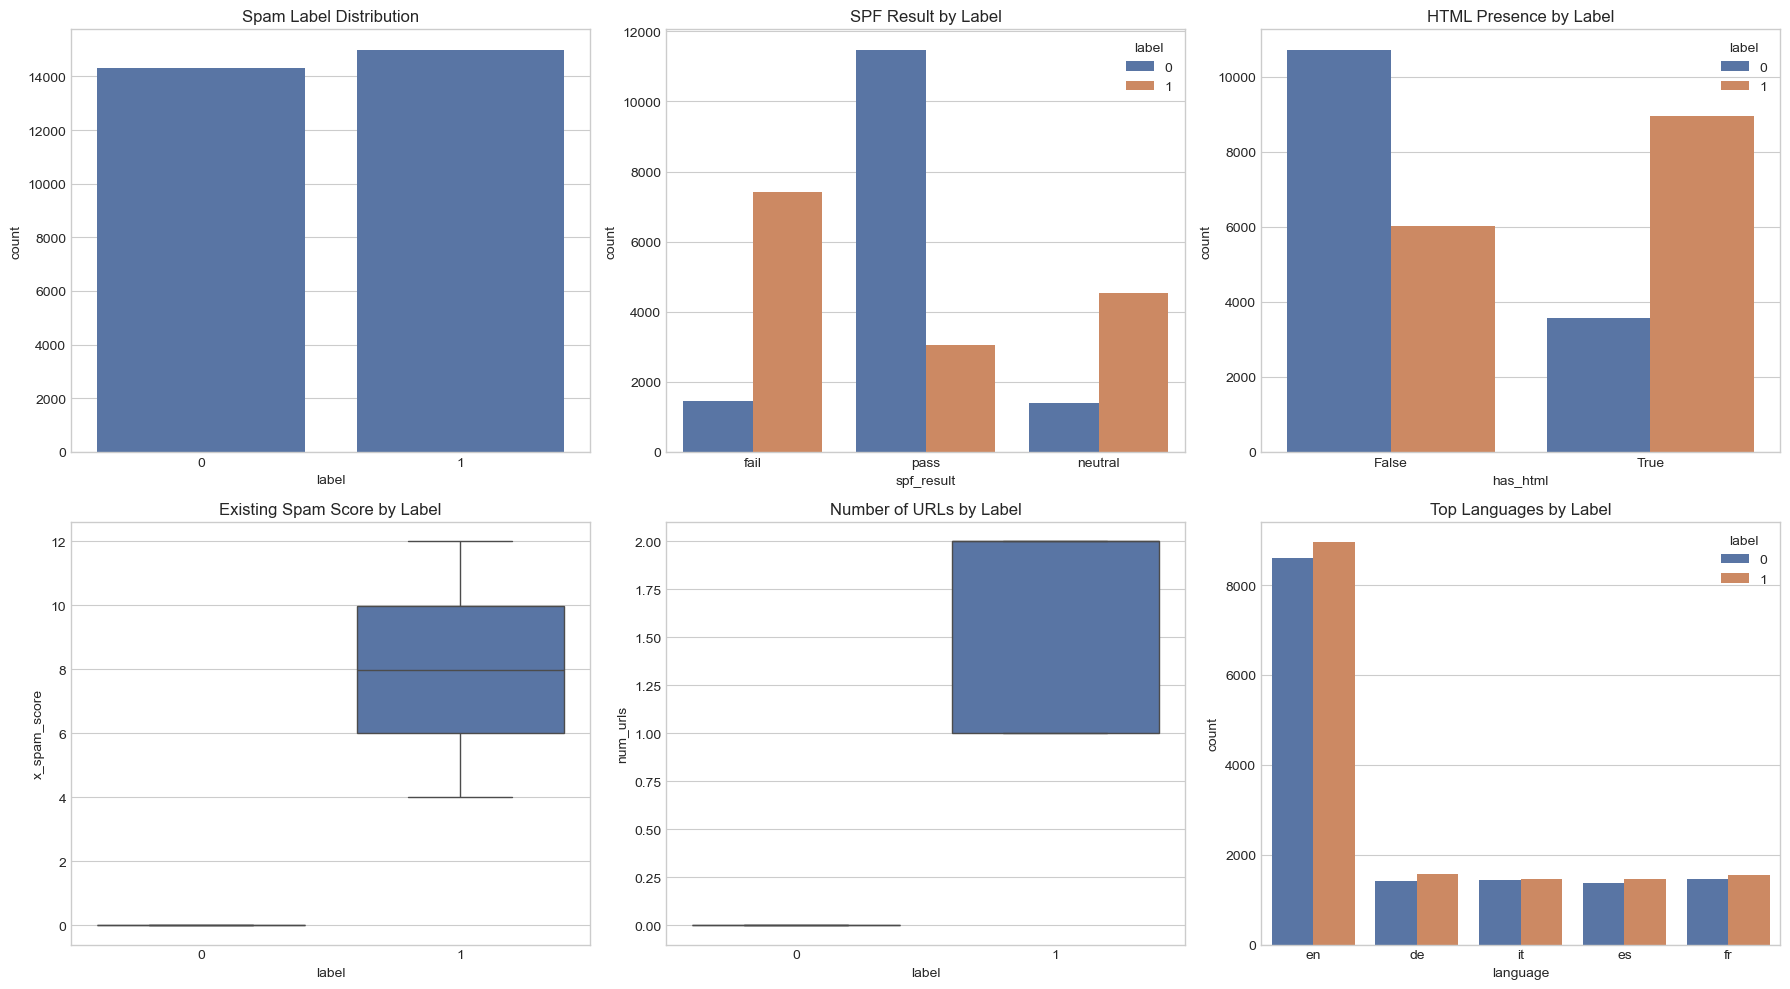

In [7]:
# Visualize the most important descriptive patterns.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=data_model, x="label", ax=axes[0, 0])
axes[0, 0].set_title("Spam Label Distribution")

sns.countplot(data=data_model, x="spf_result", hue="label", ax=axes[0, 1])
axes[0, 1].set_title("SPF Result by Label")

sns.countplot(data=data_model, x="has_html", hue="label", ax=axes[0, 2])
axes[0, 2].set_title("HTML Presence by Label")

sns.boxplot(data=data_model, x="label", y="x_spam_score", ax=axes[1, 0])
axes[1, 0].set_title("Existing Spam Score by Label")

sns.boxplot(data=data_model, x="label", y="num_urls", ax=axes[1, 1])
axes[1, 1].set_title("Number of URLs by Label")

top_languages = data_model["language"].value_counts().head(5).index
sns.countplot(
    data=data_model[data_model["language"].isin(top_languages)],
    x="language",
    hue="label",
    ax=axes[1, 2],
)
axes[1, 2].set_title("Top Languages by Label")

plt.tight_layout()
plt.show()


In [8]:
# Look at domain-level behavior and a few interpretable keyword patterns.
combined_lower = data_model["combined_text"].str.lower()

keyword_patterns = {
    "urgent_or_asap": r"urgent|asap|immediately|right away",
    "meeting_or_schedule": r"meeting|agenda|schedule|appointment|calendar|review",
    "finance": r"invoice|payment|billing|statement|accounts payable|tax",
    "delivery_or_parcel": r"parcel|delivery|shipment|tracking",
    "unsubscribe_link_present": r"unsubscribe|opt out",
}

keyword_rows = []
for name, pattern in keyword_patterns.items():
    mask = combined_lower.str.contains(pattern, regex=True, na=False)
    keyword_rows.append(
        {
            "pattern": name,
            "n_rows": int(mask.sum()),
            "spam_rate": round(float(data_model.loc[mask, "label"].mean()), 4),
        }
    )

top_ham_domains = data_model.loc[data_model["label"] == 0, "from_domain"].value_counts().head(12)
top_spam_domains = data_model.loc[data_model["label"] == 1, "from_domain"].value_counts().head(12)

print("Keyword-based diagnostic table:")
print(pd.DataFrame(keyword_rows).to_string(index=False))

print("\nTop sender domains among legitimate emails:")
print(top_ham_domains.to_string())

print("\nTop sender domains among spam emails:")
print(top_spam_domains.to_string())


Keyword-based diagnostic table:
                 pattern  n_rows  spam_rate
          urgent_or_asap    3400     1.0000
     meeting_or_schedule    9530     0.0085
                 finance    7903     0.7054
      delivery_or_parcel    4289     0.6815
unsubscribe_link_present       0        NaN

Top sender domains among legitimate emails:
from_domain
fabrikam.io          995
hr-mail.net          986
cohosu.org           964
devops.local         959
contoso.com          959
bizsupport.co        939
mycompany.com        932
globalbank.com       930
notifications.net    926
example.com          921
northwind.com        919
adatum.net           912

Top sender domains among spam emails:
from_domain
icloud.com           1826
proton.me            1791
outlook.com          1743
gmail.com            1715
yahoo.com            1691
fabrikam.io           511
notifications.net     502
accounts-mail.com     500
example.com           492
mycompany.com         489
adatum.net            485
hr-mail.ne

## Spam Classification - Modeling Strategy

We compare several approaches:
- `dummy`: a naive baseline
- `metadata_only_strict`: structured features only, without `x_spam_score`
- `text_only`: only the email text using TF-IDF
- `hybrid_strict`: text + metadata, still without `x_spam_score`
- `hybrid_full`: text + metadata + existing spam score

This lets us answer an important methodological question:

**Is the task still easy when we do not rely on a prior spam score?**


In [9]:
# Define the columns used in the spam task and create a stratified holdout split.
spam_text_col = "combined_text"

spam_numeric_strict = [
    "hour_of_day",
    "num_received_headers",
    "num_urls",
    "num_emails_in_body",
    "num_phone_numbers",
    "to_count",
    "cc_count",
    "attachment_count",
    "subject_len",
    "body_len",
    "raw_len",
    "auth_pass_count",
    "subject_exclamation_count",
    "subject_question_count",
    "subject_upper_ratio",
    "body_digit_ratio",
    "month",
]

spam_numeric_full = spam_numeric_strict + ["x_spam_score"]

spam_boolean = [
    "has_attachments",
    "has_html",
    "contains_tracking_token",
    "is_free_mail",
    "reply_to_missing",
    "has_reply_thread",
    "is_weekend",
    "is_business_hours",
]

spam_categorical = [
    "from_domain",
    "spf_result",
    "dkim_result",
    "dmarc_result",
    "user_agent",
    "language",
    "day_of_week",
]

spam_features_strict = [spam_text_col] + spam_numeric_strict + spam_boolean + spam_categorical
spam_features_full = [spam_text_col] + spam_numeric_full + spam_boolean + spam_categorical

X_spam = data_model[spam_features_strict].copy()
y_spam = data_model["label"].astype(int).copy()

X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam,
    y_spam,
    test_size=0.20,
    stratify=y_spam,
    random_state=RANDOM_STATE,
)

print("Spam train shape:", X_spam_train.shape)
print("Spam test shape :", X_spam_test.shape)
print("\nTrain label share:")
print(y_spam_train.value_counts(normalize=True).sort_index().round(4).to_string())


Spam train shape: (23446, 33)
Spam test shape : (5862, 33)

Train label share:
label
0    0.4882
1    0.5118


In [10]:
# Build reusable preprocessors and candidate models for cross-validation.
def make_spam_preprocessor(include_text=True, include_spam_score=False):
    numeric_cols = spam_numeric_full if include_spam_score else spam_numeric_strict
    transformers = []

    if include_text:
        transformers.append(
            (
                "text",
                TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True),
                spam_text_col,
            )
        )

    transformers.extend(
        [
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                spam_categorical,
            ),
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler(with_mean=False)),
                    ]
                ),
                numeric_cols,
            ),
            ("bool", "passthrough", spam_boolean),
        ]
    )

    return ColumnTransformer(transformers=transformers)


spam_models = {
    "dummy": Pipeline(
        [
            ("preprocessor", make_spam_preprocessor(include_text=False, include_spam_score=False)),
            ("classifier", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "metadata_only_strict": Pipeline(
        [
            ("preprocessor", make_spam_preprocessor(include_text=False, include_spam_score=False)),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga", class_weight="balanced")),
        ]
    ),
    "text_only": Pipeline(
        [
            (
                "preprocessor",
                ColumnTransformer(
                    [
                        (
                            "text",
                            TfidfVectorizer(
                                max_features=8000,
                                ngram_range=(1, 2),
                                min_df=3,
                                sublinear_tf=True,
                            ),
                            spam_text_col,
                        )
                    ]
                ),
            ),
            ("classifier", ComplementNB(alpha=0.5)),
        ]
    ),
    "hybrid_strict": Pipeline(
        [
            ("preprocessor", make_spam_preprocessor(include_text=True, include_spam_score=False)),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga", class_weight="balanced")),
        ]
    ),
    "hybrid_full": Pipeline(
        [
            ("preprocessor", make_spam_preprocessor(include_text=True, include_spam_score=True)),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga", class_weight="balanced")),
        ]
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring_binary = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

spam_cv_rows = []
for model_name, model in spam_models.items():
    current_X = data_model[spam_features_full] if model_name == "hybrid_full" else data_model[spam_features_strict]
    scores = cross_validate(
        model,
        current_X,
        y_spam,
        cv=cv,
        scoring=scoring_binary,
        n_jobs=1,
        return_train_score=False,
    )
    spam_cv_rows.append(
        {
            "model": model_name,
            **{metric: float(np.mean(scores[f"test_{metric}"])) for metric in scoring_binary},
        }
    )

spam_cv_results = pd.DataFrame(spam_cv_rows).sort_values("f1", ascending=False).round(4)
print("Spam CV comparison:")
print(spam_cv_results.to_string(index=False))


Spam CV comparison:
               model  accuracy  precision  recall     f1  roc_auc
           text_only    1.0000     1.0000  1.0000 1.0000      1.0
         hybrid_full    1.0000     1.0000  1.0000 1.0000      1.0
metadata_only_strict    1.0000     1.0000  0.9999 1.0000      1.0
       hybrid_strict    1.0000     1.0000  0.9999 1.0000      1.0
               dummy    0.5118     0.5118  1.0000 0.6771      0.5


In [11]:
# Fit the two most informative spam models on the holdout split:
# - hybrid_strict for academic rigor
# - hybrid_full for operational completeness
spam_model_strict = clone(spam_models["hybrid_strict"])
spam_model_full = clone(spam_models["hybrid_full"])

spam_model_strict.fit(X_spam_train, y_spam_train)
spam_model_full.fit(
    data_model.loc[X_spam_train.index, spam_features_full],
    y_spam_train,
)

spam_pred_strict = spam_model_strict.predict(X_spam_test)
spam_proba_strict = spam_model_strict.predict_proba(X_spam_test)[:, 1]

X_spam_test_full = data_model.loc[X_spam_test.index, spam_features_full]
spam_pred_full = spam_model_full.predict(X_spam_test_full)
spam_proba_full = spam_model_full.predict_proba(X_spam_test_full)[:, 1]

print("Strict model metrics:")
print(binary_metrics_dataframe(y_spam_test, spam_pred_strict, spam_proba_strict).to_string(index=False))
print("\nFull model metrics:")
print(binary_metrics_dataframe(y_spam_test, spam_pred_full, spam_proba_full).to_string(index=False))

print("\nStrict model classification report:")
print(classification_report(y_spam_test, spam_pred_strict, digits=4))


Strict model metrics:
 accuracy  precision  recall  f1  roc_auc  pr_auc
      1.0        1.0     1.0 1.0      1.0     1.0

Full model metrics:
 accuracy  precision  recall  f1  roc_auc  pr_auc
      1.0        1.0     1.0 1.0      1.0     1.0

Strict model classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      2862
           1     1.0000    1.0000    1.0000      3000

    accuracy                         1.0000      5862
   macro avg     1.0000    1.0000    1.0000      5862
weighted avg     1.0000    1.0000    1.0000      5862



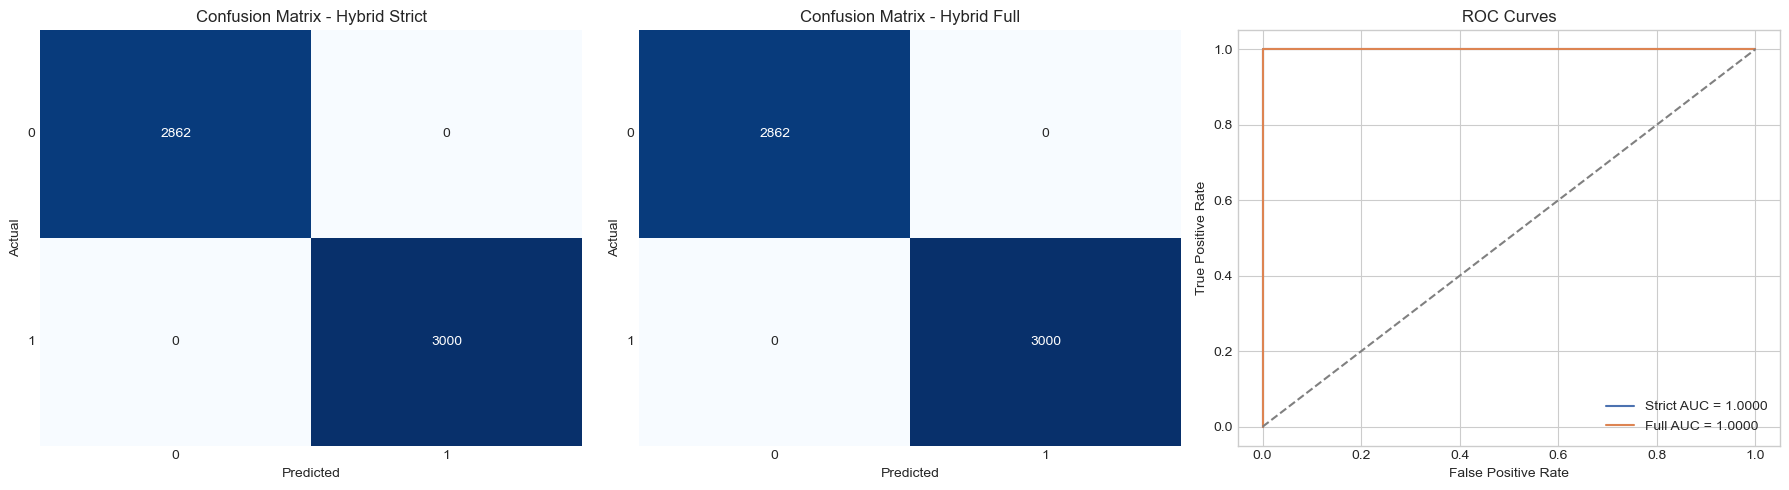

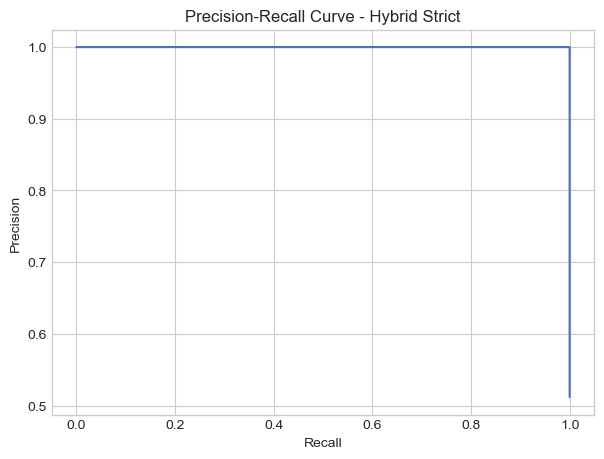

In [12]:
# Visualize confusion matrices and probability curves for the spam models.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion(axes[0], y_spam_test, spam_pred_strict, labels=[0, 1], title="Confusion Matrix - Hybrid Strict")
plot_confusion(axes[1], y_spam_test, spam_pred_full, labels=[0, 1], title="Confusion Matrix - Hybrid Full")

fpr_strict, tpr_strict, _ = roc_curve(y_spam_test, spam_proba_strict)
fpr_full, tpr_full, _ = roc_curve(y_spam_test, spam_proba_full)
axes[2].plot(fpr_strict, tpr_strict, label=f"Strict AUC = {roc_auc_score(y_spam_test, spam_proba_strict):.4f}")
axes[2].plot(fpr_full, tpr_full, label=f"Full AUC = {roc_auc_score(y_spam_test, spam_proba_full):.4f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[2].set_title("ROC Curves")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_spam_test, spam_proba_strict)
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve)
plt.title("Precision-Recall Curve - Hybrid Strict")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


Threshold sensitivity table:
 threshold  precision  recall     f1
      0.05     0.9997     1.0 0.9998
      0.10     1.0000     1.0 1.0000
      0.15     1.0000     1.0 1.0000
      0.20     1.0000     1.0 1.0000
      0.25     1.0000     1.0 1.0000
      0.30     1.0000     1.0 1.0000
      0.35     1.0000     1.0 1.0000
      0.40     1.0000     1.0 1.0000
      0.45     1.0000     1.0 1.0000
      0.50     1.0000     1.0 1.0000
      0.55     1.0000     1.0 1.0000
      0.60     1.0000     1.0 1.0000
      0.65     1.0000     1.0 1.0000
      0.70     1.0000     1.0 1.0000
      0.75     1.0000     1.0 1.0000
      0.80     1.0000     1.0 1.0000
      0.85     1.0000     1.0 1.0000
      0.90     1.0000     1.0 1.0000
      0.95     1.0000     1.0 1.0000

Best threshold according to F1, then recall, then precision:
 threshold  precision  recall  f1
       0.1        1.0     1.0 1.0


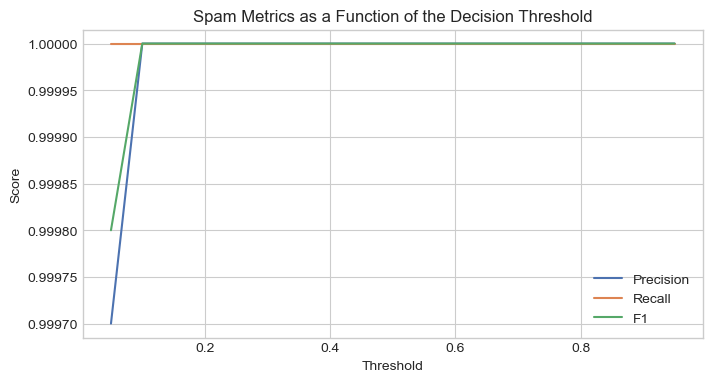

In [13]:
# Explore decision-threshold sensitivity for the strict spam model.
spam_thresholds = threshold_report(y_spam_test, spam_proba_strict)
best_threshold_row = spam_thresholds.sort_values(["f1", "recall", "precision"], ascending=False).head(1)

print("Threshold sensitivity table:")
print(spam_thresholds.to_string(index=False))

print("\nBest threshold according to F1, then recall, then precision:")
print(best_threshold_row.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(spam_thresholds["threshold"], spam_thresholds["precision"], label="Precision")
plt.plot(spam_thresholds["threshold"], spam_thresholds["recall"], label="Recall")
plt.plot(spam_thresholds["threshold"], spam_thresholds["f1"], label="F1")
plt.title("Spam Metrics as a Function of the Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()


In [14]:
# Perform a temporal validation to mimic a more realistic production setting.
data_time = data_model.sort_values("date").reset_index(drop=True)
time_cutoff = data_time["date"].quantile(0.80)

train_time = data_time[data_time["date"] <= time_cutoff].copy()
test_time = data_time[data_time["date"] > time_cutoff].copy()

spam_time_model = clone(spam_models["hybrid_strict"])
spam_time_model.fit(train_time[spam_features_strict], train_time["label"])

spam_time_pred = spam_time_model.predict(test_time[spam_features_strict])
spam_time_proba = spam_time_model.predict_proba(test_time[spam_features_strict])[:, 1]

print("Temporal split cutoff:", time_cutoff)
print("Temporal train shape:", train_time.shape)
print("Temporal test shape :", test_time.shape)
print("\nTemporal validation metrics:")
print(binary_metrics_dataframe(test_time["label"], spam_time_pred, spam_time_proba).to_string(index=False))


Temporal split cutoff: 2025-06-05 11:18:45.600000
Temporal train shape: (23446, 49)
Temporal test shape : (5862, 49)

Temporal validation metrics:
 accuracy  precision  recall  f1  roc_auc  pr_auc
      1.0        1.0     1.0 1.0      1.0     1.0


In [15]:
# Check whether spam performance stays strong across useful operational subgroups.
spam_robustness = X_spam_test.copy()
spam_robustness["actual_label"] = y_spam_test.values
spam_robustness["predicted_label"] = spam_pred_strict

robustness_tables = {
    "language": group_binary_performance(spam_robustness, "language", "actual_label", "predicted_label"),
    "has_html": group_binary_performance(spam_robustness, "has_html", "actual_label", "predicted_label"),
    "is_free_mail": group_binary_performance(spam_robustness, "is_free_mail", "actual_label", "predicted_label"),
    "has_attachments": group_binary_performance(spam_robustness, "has_attachments", "actual_label", "predicted_label"),
}

for name, table in robustness_tables.items():
    print(f"\nRobustness by {name}:")
    print(table.to_string(index=False))



Robustness by language:
language  n_rows  accuracy  precision  recall  f1
      en    3483       1.0        1.0     1.0 1.0
      fr     623       1.0        1.0     1.0 1.0
      de     603       1.0        1.0     1.0 1.0
      it     584       1.0        1.0     1.0 1.0
      es     569       1.0        1.0     1.0 1.0

Robustness by has_html:
 has_html  n_rows  accuracy  precision  recall  f1
    False    3395       1.0        1.0     1.0 1.0
     True    2467       1.0        1.0     1.0 1.0

Robustness by is_free_mail:
 is_free_mail  n_rows  accuracy  precision  recall  f1
        False    3681       1.0        1.0     1.0 1.0
         True    2181       1.0        1.0     1.0 1.0

Robustness by has_attachments:
 has_attachments  n_rows  accuracy  precision  recall  f1
           False    4671       1.0        1.0     1.0 1.0
            True    1191       1.0        1.0     1.0 1.0


Top spam-indicative features:
                       feature  coefficient
                 num__num_urls     6.654825
        num__num_phone_numbers     1.945038
 bool__contains_tracking_token     1.076247
       num__num_emails_in_body     0.506343
            bool__is_free_mail     0.482244
num__subject_exclamation_count     0.414946
                 num__body_len     0.375553
                   text__https     0.326985
       cat__user_agent_aws-ses     0.322898
       cat__user_agent_mailgun     0.305192
    cat__user_agent_nodemailer     0.293690
     cat__user_agent_PHPMailer     0.275607
      cat__user_agent_sendgrid     0.245083
                  text__verify     0.237078
                     text__now     0.223317

Top legitimate-email features:
                   feature  coefficient
      num__auth_pass_count    -1.331528
             num__to_count    -1.147702
    bool__reply_to_missing    -1.130731
    bool__has_reply_thread    -1.019805
            bool__has_html    -0.8

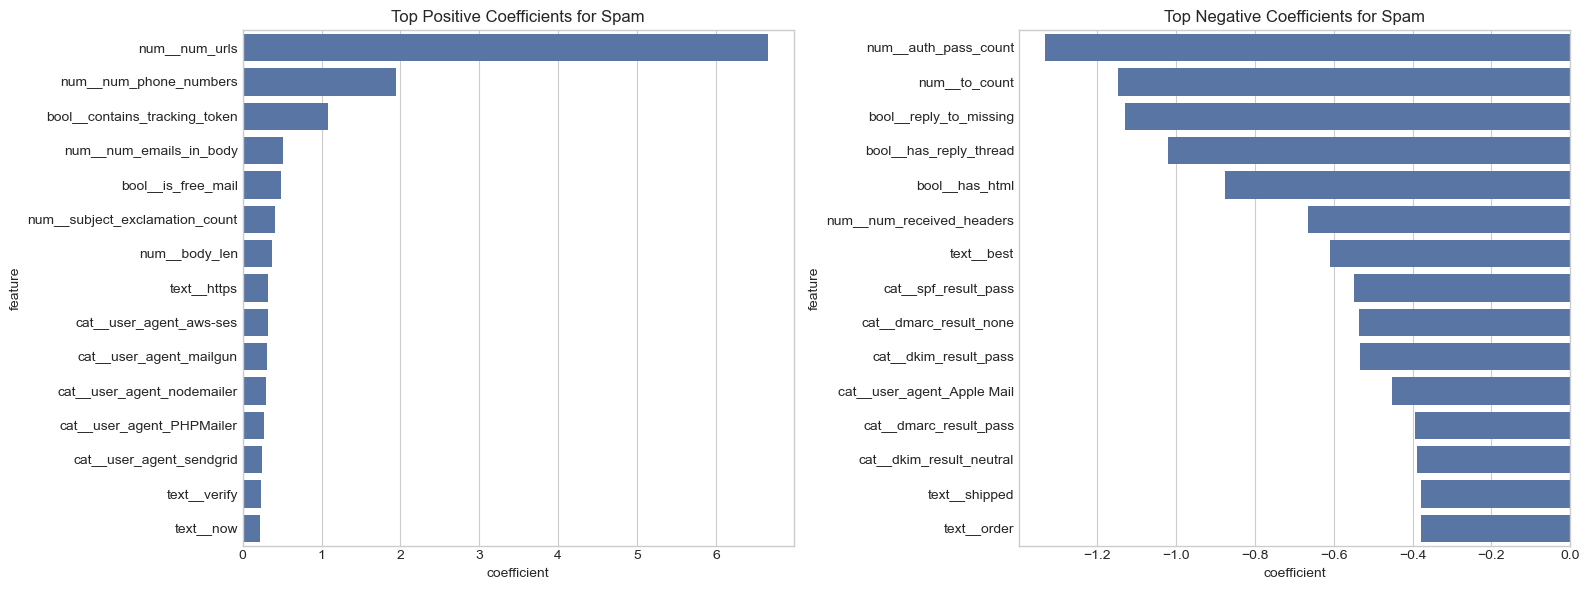

In [16]:
# Interpret the strict spam model by looking at the largest positive and negative coefficients.
strict_feature_names = try_get_feature_names(spam_model_strict.named_steps["preprocessor"])

if strict_feature_names is not None:
    strict_coefficients = pd.DataFrame(
        {
            "feature": strict_feature_names,
            "coefficient": spam_model_strict.named_steps["classifier"].coef_.ravel(),
        }
    ).sort_values("coefficient", ascending=False)

    top_spam_features = strict_coefficients.head(15)
    top_ham_features = strict_coefficients.tail(15).sort_values("coefficient")

    print("Top spam-indicative features:")
    print(top_spam_features.to_string(index=False))

    print("\nTop legitimate-email features:")
    print(top_ham_features.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_spam_features, x="coefficient", y="feature", ax=axes[0])
    axes[0].set_title("Top Positive Coefficients for Spam")

    sns.barplot(data=top_ham_features, x="coefficient", y="feature", ax=axes[1])
    axes[1].set_title("Top Negative Coefficients for Spam")

    plt.tight_layout()
    plt.show()
else:
    print("Feature names could not be extracted in this environment.")


In [17]:
# Inspect false positives and false negatives to understand failure modes.
spam_errors = X_spam_test.copy()
spam_errors["actual_label"] = y_spam_test.values
spam_errors["predicted_label"] = spam_pred_strict
spam_errors["predicted_proba_spam"] = spam_proba_strict
spam_errors["subject"] = data_model.loc[X_spam_test.index, "subject"].values
spam_errors["from_domain"] = data_model.loc[X_spam_test.index, "from_domain"].values

false_positives = spam_errors.query("actual_label == 0 and predicted_label == 1").sort_values(
    "predicted_proba_spam", ascending=False
)
false_negatives = spam_errors.query("actual_label == 1 and predicted_label == 0").sort_values(
    "predicted_proba_spam", ascending=True
)

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

if len(false_positives) > 0:
    print("\nTop false positives:")
    print(false_positives[["subject", "from_domain", "predicted_proba_spam"]].head(10).to_string(index=False))

if len(false_negatives) > 0:
    print("\nTop false negatives:")
    print(false_negatives[["subject", "from_domain", "predicted_proba_spam"]].head(10).to_string(index=False))

if len(false_positives) == 0 and len(false_negatives) == 0:
    print("\nNo holdout errors were observed with the strict spam model on this dataset.")


Number of false positives: 0
Number of false negatives: 0

No holdout errors were observed with the strict spam model on this dataset.


## Importance Modeling for Non-Spam Emails

Since the CSV does not provide a human-labeled importance target, we build a transparent **business importance score** on legitimate emails only.

### Logic used

Positive signals:
- reply thread
- attachments
- scheduling / meeting language
- finance / approval language
- project / report language
- non-free sender domain
- strong authentication
- additional recipients in `cc`
- sent during business hours

Negative signals:
- unsubscribe signal
- too many URLs
- tracking token

The resulting continuous score is then converted into three balanced levels using empirical quantiles:
- `low`
- `medium`
- `high`

This is not a ground-truth annotation, but it is a transparent and reproducible proxy target.


In [18]:
# Restrict the second task to legitimate emails and build a transparent importance score.
ham_data = data_model.loc[data_model["label"] == 0].copy().reset_index(drop=True)
ham_text_lower = ham_data["combined_text"].str.lower()

ham_data["score_reply_thread"] = 2.2 * ham_data["has_reply_thread"].astype(int)
ham_data["score_attachment"] = 1.8 * ham_data["has_attachments"].astype(int)
ham_data["score_schedule_keywords"] = 1.5 * ham_text_lower.str.contains(
    r"meeting|agenda|call|appointment|schedule|calendar|deadline|due date|review|follow-up|follow up|reminder",
    regex=True,
    na=False,
).astype(int)
ham_data["score_finance_keywords"] = 1.2 * ham_text_lower.str.contains(
    r"invoice|payment|billing|statement|accounts payable|budget|contract|legal|approval",
    regex=True,
    na=False,
).astype(int)
ham_data["score_project_keywords"] = 1.0 * ham_text_lower.str.contains(
    r"release notes|report|weekly update|project|onboarding|it|legal",
    regex=True,
    na=False,
).astype(int)
ham_data["score_business_domain"] = 0.8 * (~ham_data["is_free_mail"]).astype(int)
ham_data["score_authentication"] = 0.6 * (ham_data["auth_pass_count"] >= 2).astype(int)
ham_data["score_cc"] = 0.4 * (ham_data["cc_count"] > 0).astype(int)
ham_data["score_business_hours"] = 0.3 * ham_data["is_business_hours"].astype(int)

ham_data["penalty_unsubscribe"] = -0.8 * ham_data["list_unsubscribe"].notna().astype(int)
ham_data["penalty_urls"] = -0.8 * (ham_data["num_urls"] >= 1).astype(int)
ham_data["penalty_tracking"] = -0.5 * ham_data["contains_tracking_token"].astype(int)

importance_components = [
    "score_reply_thread",
    "score_attachment",
    "score_schedule_keywords",
    "score_finance_keywords",
    "score_project_keywords",
    "score_business_domain",
    "score_authentication",
    "score_cc",
    "score_business_hours",
    "penalty_unsubscribe",
    "penalty_urls",
    "penalty_tracking",
]

ham_data["importance_score"] = ham_data[importance_components].sum(axis=1)

q33, q66 = ham_data["importance_score"].quantile([0.33, 0.66]).tolist()
ham_data["importance_level"] = pd.cut(
    ham_data["importance_score"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=["low", "medium", "high"],
)

print("Importance score summary:")
print(ham_data["importance_score"].describe().round(4).to_string())

print("\nQuantile cutoffs:")
print({"q33": round(q33, 4), "q66": round(q66, 4)})

print("\nImportance level distribution:")
print(ham_data["importance_level"].value_counts().to_string())


Importance score summary:
count    14308.0000
mean         4.3019
std          1.5418
min          0.0000
25%          3.2000
50%          4.2000
75%          5.4000
max          9.8000

Quantile cutoffs:
{'q33': 3.4, 'q66': 4.9}

Importance level distribution:
importance_level
high      4858
low       4789
medium    4661


Importance-level sanity check:
                  has_reply_thread  has_attachments  auth_pass_count  num_urls  cc_count  importance_score
importance_level                                                                                          
low                         0.0121           0.0161           2.2201       0.0    0.4615            2.6705
medium                      0.1806           0.1304           2.3089       0.0    0.6381            4.1549
high                        0.7071           0.3158           2.3954       0.0    0.6665            6.0513


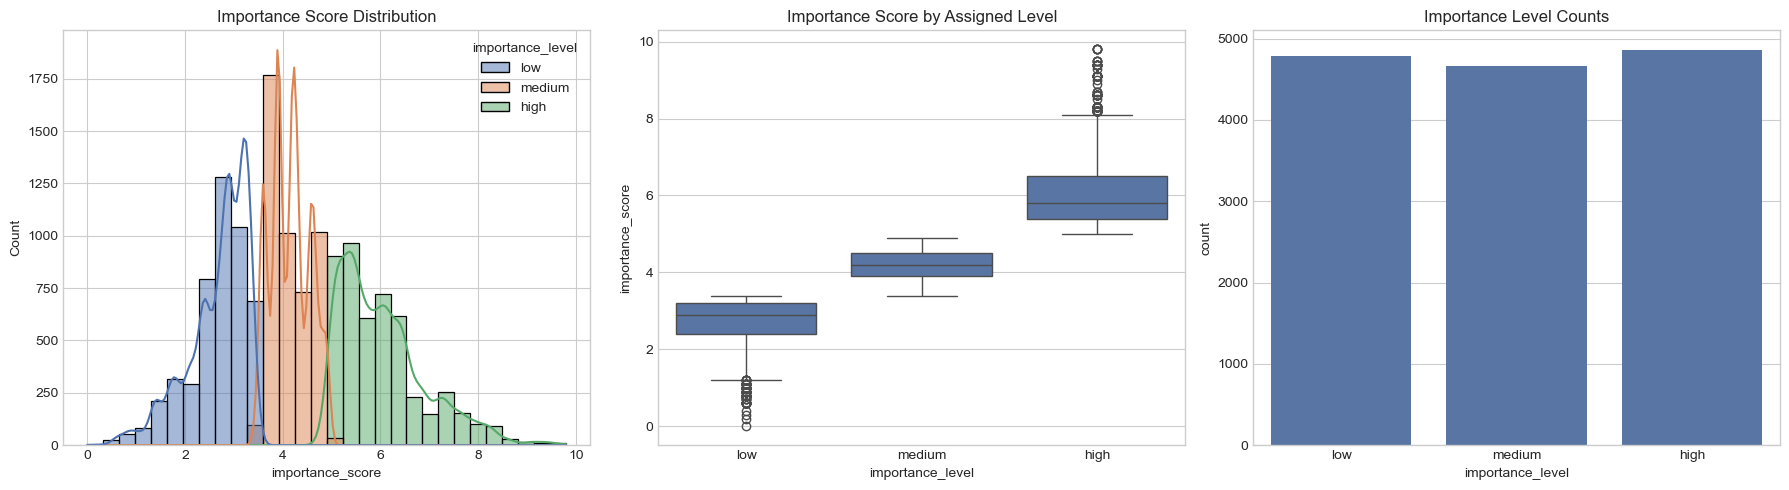

In [19]:
# Sanity-check the importance target with descriptive views and simple business diagnostics.
importance_summary = (
    ham_data.groupby("importance_level")[
        [
            "has_reply_thread",
            "has_attachments",
            "auth_pass_count",
            "num_urls",
            "cc_count",
            "importance_score",
        ]
    ]
    .mean()
    .round(4)
)

print("Importance-level sanity check:")
print(importance_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=ham_data, x="importance_score", hue="importance_level", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Importance Score Distribution")

sns.boxplot(data=ham_data, x="importance_level", y="importance_score", ax=axes[1], order=["low", "medium", "high"])
axes[1].set_title("Importance Score by Assigned Level")

sns.countplot(data=ham_data, x="importance_level", order=["low", "medium", "high"], ax=axes[2])
axes[2].set_title("Importance Level Counts")

plt.tight_layout()
plt.show()


In [20]:
# Prepare features for multiclass importance prediction.
importance_text_col = "combined_text"

importance_numeric = [
    "hour_of_day",
    "num_received_headers",
    "num_urls",
    "num_emails_in_body",
    "num_phone_numbers",
    "to_count",
    "cc_count",
    "attachment_count",
    "subject_len",
    "body_len",
    "raw_len",
    "auth_pass_count",
    "subject_exclamation_count",
    "subject_question_count",
    "subject_upper_ratio",
    "body_digit_ratio",
    "month",
    "importance_score",
]

importance_boolean = [
    "has_attachments",
    "has_html",
    "contains_tracking_token",
    "is_free_mail",
    "reply_to_missing",
    "has_reply_thread",
    "is_weekend",
    "is_business_hours",
]

importance_categorical = [
    "from_domain",
    "spf_result",
    "dkim_result",
    "dmarc_result",
    "user_agent",
    "language",
    "day_of_week",
]

importance_features = [importance_text_col] + importance_numeric + importance_boolean + importance_categorical

X_importance = ham_data[importance_features].copy()
y_importance = ham_data["importance_level"].copy()

X_imp_train, X_imp_test, y_imp_train, y_imp_test = train_test_split(
    X_importance,
    y_importance,
    test_size=0.20,
    stratify=y_importance,
    random_state=RANDOM_STATE,
)

print("Importance train shape:", X_imp_train.shape)
print("Importance test shape :", X_imp_test.shape)
print("\nImportance target share:")
print(y_importance.value_counts(normalize=True).round(4).to_string())


Importance train shape: (11446, 34)
Importance test shape : (2862, 34)

Importance target share:
importance_level
high      0.3395
low       0.3347
medium    0.3258


In [21]:
# Build candidate multiclass models for the importance task.
def make_importance_preprocessor(include_text=True):
    transformers = []

    if include_text:
        transformers.append(
            (
                "text",
                TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True),
                importance_text_col,
            )
        )

    transformers.extend(
        [
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                importance_categorical,
            ),
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler(with_mean=False)),
                    ]
                ),
                importance_numeric,
            ),
            ("bool", "passthrough", importance_boolean),
        ]
    )

    return ColumnTransformer(transformers=transformers)


importance_models = {
    "dummy": Pipeline(
        [
            ("preprocessor", make_importance_preprocessor(include_text=False)),
            ("classifier", DummyClassifier(strategy="prior")),
        ]
    ),
    "metadata_only": Pipeline(
        [
            ("preprocessor", make_importance_preprocessor(include_text=False)),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga")),
        ]
    ),
    "text_only": Pipeline(
        [
            (
                "preprocessor",
                ColumnTransformer(
                    [
                        (
                            "text",
                            TfidfVectorizer(
                                max_features=8000,
                                ngram_range=(1, 2),
                                min_df=3,
                                sublinear_tf=True,
                            ),
                            importance_text_col,
                        )
                    ]
                ),
            ),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga")),
        ]
    ),
    "hybrid": Pipeline(
        [
            ("preprocessor", make_importance_preprocessor(include_text=True)),
            ("classifier", LogisticRegression(max_iter=2500, solver="saga")),
        ]
    ),
}

scoring_multiclass = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_precision": "precision_macro",
    "macro_recall": "recall_macro",
}

importance_cv_rows = []
for model_name, model in importance_models.items():
    scores = cross_validate(
        model,
        X_importance,
        y_importance,
        cv=cv,
        scoring=scoring_multiclass,
        n_jobs=1,
        return_train_score=False,
    )
    importance_cv_rows.append(
        {
            "model": model_name,
            **{metric: float(np.mean(scores[f"test_{metric}"])) for metric in scoring_multiclass},
        }
    )

importance_cv_results = pd.DataFrame(importance_cv_rows).sort_values("macro_f1", ascending=False).round(4)
print("Importance CV comparison:")
print(importance_cv_results.to_string(index=False))


Importance CV comparison:
        model  accuracy  macro_f1  macro_precision  macro_recall
metadata_only    0.9920    0.9920           0.9920        0.9920
       hybrid    0.9854    0.9853           0.9853        0.9853
    text_only    0.5026    0.4929           0.4943        0.5017
        dummy    0.3395    0.1690           0.1132        0.3333


In [22]:
# Fit the final multiclass importance model on the holdout split.
importance_model_final = clone(importance_models["hybrid"])
importance_model_final.fit(X_imp_train, y_imp_train)

importance_pred = importance_model_final.predict(X_imp_test)
importance_proba = importance_model_final.predict_proba(X_imp_test)

print("Final importance model metrics:")
print(multiclass_metrics_dataframe(y_imp_test, importance_pred, importance_proba).to_string(index=False))

print("\nImportance classification report:")
print(classification_report(y_imp_test, importance_pred, digits=4))


Final importance model metrics:
 accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc_ovr
   0.9888    0.9888           0.9888        0.9888             0.9997

Importance classification report:
              precision    recall  f1-score   support

        high     0.9907    0.9877    0.9892       972
         low     0.9958    0.9927    0.9942       958
      medium     0.9797    0.9861    0.9829       932

    accuracy                         0.9888      2862
   macro avg     0.9888    0.9888    0.9888      2862
weighted avg     0.9888    0.9888    0.9888      2862



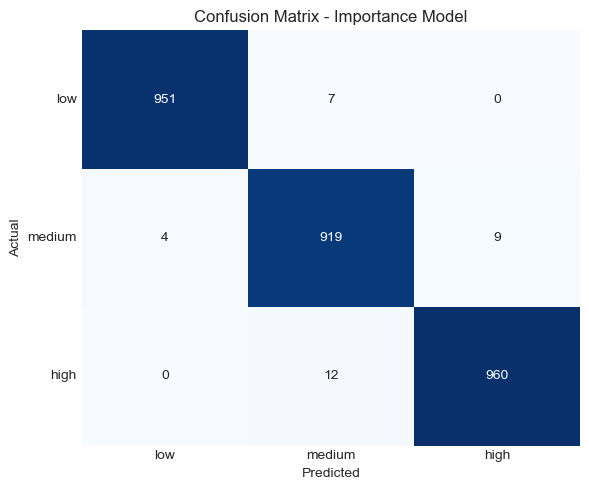

In [23]:
# Visualize the multiclass confusion matrix.
plt.figure(figsize=(6, 5))
plot_confusion(
    plt.gca(),
    y_imp_test,
    importance_pred,
    labels=["low", "medium", "high"],
    title="Confusion Matrix - Importance Model",
)
plt.tight_layout()
plt.show()


In [24]:
# Measure robustness of the importance model across a few practical subgroups.
importance_robustness = X_imp_test.copy()
importance_robustness["actual_level"] = y_imp_test.values
importance_robustness["predicted_level"] = importance_pred

importance_group_tables = {
    "language": group_multiclass_performance(importance_robustness, "language", "actual_level", "predicted_level"),
    "has_attachments": group_multiclass_performance(importance_robustness, "has_attachments", "actual_level", "predicted_level"),
    "is_free_mail": group_multiclass_performance(importance_robustness, "is_free_mail", "actual_level", "predicted_level"),
}

for name, table in importance_group_tables.items():
    print(f"\nImportance robustness by {name}:")
    print(table.to_string(index=False))



Importance robustness by language:
language  n_rows  accuracy  macro_f1
      en    1697    0.9900    0.9900
      fr     306    0.9869    0.9870
      it     301    0.9867    0.9868
      es     283    0.9894    0.9891
      de     275    0.9855    0.9853

Importance robustness by has_attachments:
 has_attachments  n_rows  accuracy  macro_f1
           False    2414    0.9901    0.9898
            True     448    0.9821    0.9847

Importance robustness by is_free_mail:
 is_free_mail  n_rows  accuracy  macro_f1
        False    2446    0.9902    0.9905
         True     416    0.9808    0.9768


In [25]:
# Interpret the multiclass model by inspecting coefficients for each class.
importance_feature_names = try_get_feature_names(importance_model_final.named_steps["preprocessor"])

if importance_feature_names is not None:
    coef_matrix = importance_model_final.named_steps["classifier"].coef_
    class_labels = importance_model_final.named_steps["classifier"].classes_

    for class_index, class_name in enumerate(class_labels):
        coef_table = pd.DataFrame(
            {
                "feature": importance_feature_names,
                "coefficient": coef_matrix[class_index],
            }
        ).sort_values("coefficient", ascending=False)

        print(f"\nTop features for class '{class_name}':")
        print(coef_table.head(12).to_string(index=False))
else:
    print("Feature names could not be extracted in this environment.")



Top features for class 'high':
                      feature  coefficient
        num__importance_score    13.130337
bool__contains_tracking_token     1.624382
                num__body_len     1.030175
                text__meeting     0.994646
               text__calendar     0.959475
       bool__has_reply_thread     0.895029
                    text__and     0.842293
                     text__re     0.807641
          text__meeting notes     0.807641
              text__notes for     0.807641
             text__re meeting     0.807641
                  text__legal     0.714548

Top features for class 'low':
                 feature  coefficient
           num__to_count     5.880381
   cat__dkim_result_fail     2.849951
  cat__dmarc_result_fail     2.788828
 cat__spf_result_neutral     2.785626
            num__raw_len     2.770110
cat__dkim_result_neutral     2.698071
  cat__dmarc_result_none     2.673887
    cat__spf_result_fail     2.667961
    num__auth_pass_count     1.63307

In [26]:
# Show concrete email examples per importance level to connect the model with real messages.
importance_examples = ham_data.loc[X_imp_test.index, ["subject", "from_domain", "importance_score"]].copy()
importance_examples["actual_level"] = y_imp_test.values
importance_examples["predicted_level"] = importance_pred

for level in ["low", "medium", "high"]:
    print(f"\nExample messages for actual importance level = {level}:")
    subset = importance_examples[importance_examples["actual_level"] == level].head(5)
    print(subset.to_string(index=False))



Example messages for actual importance level = low:
                            subject   from_domain  importance_score actual_level predicted_level
Holiday calendar and office closure bizsupport.co               3.3          low             low
           Minutes: Finance standup mycompany.com               1.8          low             low
    Schedule confirmation (Dropbox) northwind.com               3.4          low             low
           Re: Meeting notes for HR   contoso.com               2.9          low             low
         Patch deployment scheduled     gmail.com               1.9          low             low

Example messages for actual importance level = medium:
                                subject    from_domain  importance_score actual_level predicted_level
        Action items from sprint review   devops.local               4.3       medium          medium
Schedule confirmation (Google Calendar)     adatum.net               4.4       medium          medium
   

## Final Interpretation

### Main findings

- The spam task is extremely easy on this dataset, even after deduplication and even without relying on `x_spam_score`.
- This suggests that the dataset is synthetic and contains strong textual and metadata patterns that separate spam from ham very clearly.
- The importance task is much harder, which is normal:
  - there is no native ground-truth importance label
  - the target is a transparent business proxy rather than a real annotation
  - borderline cases between `low`, `medium`, and `high` remain ambiguous

### Practical conclusion

A realistic production workflow can therefore use a **two-stage pipeline**:

1. **Stage 1 - Spam filter**
   - block or quarantine obvious spam
   - keep a probability score for analyst review if desired

2. **Stage 2 - Importance ranking on legitimate emails**
   - assign `low / medium / high`
   - sort the inbox by urgency or business value
   - enrich the UI with reasons such as:
     - reply thread detected
     - meeting-related content
     - attachment present
     - trusted domain and authentication

### Recommended next step

The next logical extension is exactly the one planned for this project:
connect a local LLM through LM Studio so that, after the structured ML layer, a chatbot can explain why an email is safe or risky and can answer calendar-like questions from the inbox content.
